# Квантовая эффективность


## 1. Импорт библиотек

In [55]:
import os
import re
import glob
from collections import defaultdict, OrderedDict
from typing import List, Dict, Tuple, Any

import numpy as np

from scipy import interpolate, stats
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d,UnivariateSpline
from scipy.integrate import trapezoid

import matplotlib.pyplot as plt
from cycler import cycler
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FormatStrFormatter, StrMethodFormatter

# Настройки визуализации
#plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 100,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "lines.linewidth": 1.5,
    "errorbar.capsize": 1.5,
    "image.cmap": "viridis",
    "axes.prop_cycle": cycler(color=plt.cm.plasma(np.linspace(0, 1, 11)))
})

SAVE_FIGS = False
FIG_DPI = 600

%matplotlib notebook


### Утилиты

In [56]:
def angle2energy(angle: float) -> float:
    """Перевод угла (градусы) в энергию (кэВ)"""
    
    return 12.39841 / (2 * (5.341 / np.sqrt(3)) * np.sin(np.deg2rad(angle + 0.299)))


## 2. Загрузка данных о фототоке

1. Названия файлов [ВАХ]:

`x v y deg z mA` — прикладываемое напряжение `x` В на энергии, соответсвующей углу монохроматора `y` градусов с током накопителя `z` мА.

2. Заголовки файлов [ВАХ]:

`Время (мс)` — абсолютное время, по нему проводится усреднение;

`Сигнал (В)` — значение напряжения с PIN-диода.

In [57]:
# конечная группировка: напряжение -> [(энергия, фототок, ошибка, ток накопителя)]
grouped_by_voltage = defaultdict(list)

pat = re.compile(
    r"(\d+[\.,]?\d*)\s*v\s*(\d+[\.,]?\d*)\s*deg\s*(\d+[\.,]?\d*)\s*mA\.txt"
)

for path in glob.glob("Филипп/* v * deg * mA.txt"):
    m = pat.search(path)
    if not m:
        continue

    try:
        V = -float(m.group(1).replace(",", "."))
        E = angle2energy(float(m.group(2).replace(",", ".")))
        Ib = float(m.group(3).replace(",", "."))

        with open(path, "r", encoding="utf-8") as f:
            d = np.loadtxt(f, skiprows=1, delimiter=",")
        I = np.mean(d[:, 1]) / 300          # фототок: мА = В/300 кОм
        dI = stats.sem(d[:, 1]) / 300       # ошибка среднего

        grouped_by_voltage[V].append((E, I, dI, Ib))

    except Exception as e:
        print(f"[!] Ошибка при обработке файла {path}: {e}")

grouped_by_voltage = {
    V: sorted(rows, key=lambda x: x[0])
    for V, rows in sorted(grouped_by_voltage.items())
}

# проверка на адекваность загрузки данных

for V, rows in grouped_by_voltage.items():
    arr = np.array(rows)
    print(f"Напряжение {V:.2f} В")
    print(f"  Энергия: {arr[:, 0]} кэВ")
    print(f"  Фототок: {arr[:, 1]} +/- {arr[:, 2]} мА")
    print(f"  Ток накопителя: {arr[:, 3]} mA")


Напряжение -60.00 В
  Энергия: [ 4.53269038  6.61267209  8.66271757 10.70032653 12.71247242 14.70253001
 16.66422911 18.61755573 20.53213098 22.44401324] кэВ
  Фототок: [-1.22781168e-05 -1.22984118e-05 -2.10132394e-05 -6.49397047e-05
 -1.05700703e-04 -1.07290397e-04 -5.59402686e-05 -4.69655854e-05
 -1.94214188e-05 -1.24767010e-05] +/- [3.75802075e-08 9.36713422e-09 2.39521257e-08 1.03230421e-07
 8.01795086e-08 5.67855146e-08 5.12215391e-08 6.65546800e-08
 3.37372770e-08 6.38032878e-08] мА
  Ток накопителя: [7.324 7.2   7.19  7.074 7.06  6.993 3.714 3.714 3.714 3.772] mA
Напряжение -50.00 В
  Энергия: [ 4.53269038  6.61267209  8.66271757 10.70032653 12.71247242 14.70253001
 16.66422911 18.61755573 20.53213098 22.44401324] кэВ
  Фототок: [-1.14348717e-05 -1.15955631e-05 -2.03266410e-05 -6.36563934e-05
 -1.03411088e-04 -1.06847366e-04 -5.48460545e-05 -4.57801107e-05
 -1.85878054e-05 -1.17566225e-05] +/- [3.01183808e-08 9.62728745e-08 1.07938387e-07 2.94866917e-08
 3.95294076e-08 7.7904668

C:\Users\nmurz\AppData\Local\Temp\ipykernel_20908\1105392963.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


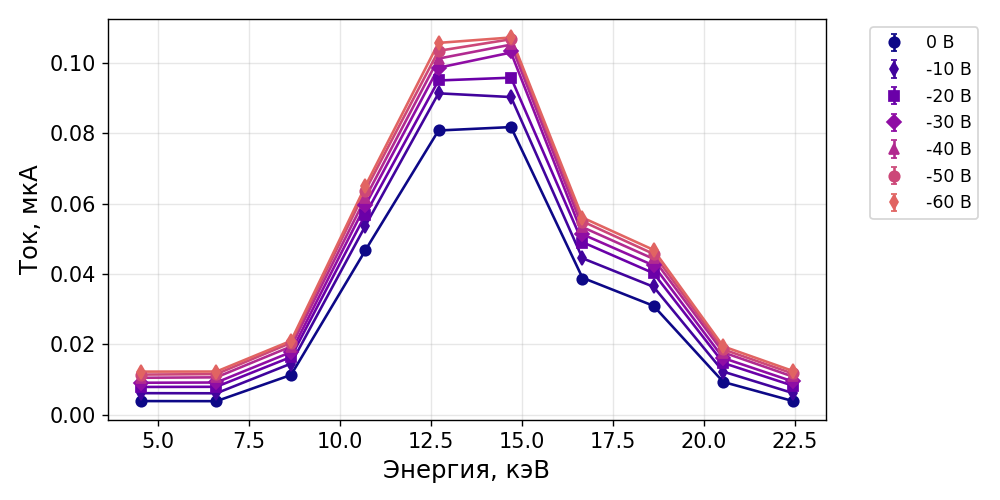

In [58]:
interpolations_V = {}

for V, arr in grouped_by_voltage.items():
    arr = np.array(arr)
    energies = arr[:, 0]
    currents = arr[:, 1]
    errors = arr[:, 2]

    interpolations_V[V] = UnivariateSpline(
        energies, currents, w=1/errors, k=1
    )

voltages_to_plot = [0, -10, -20, -30, -40, -50, -60]

fig, ax = plt.subplots(figsize=(8,4))
markers = ["o", "d", "s", "D", "^"] * 3

for i, V in enumerate(voltages_to_plot):
    if V not in grouped_by_voltage:
        continue

    arr = np.array(grouped_by_voltage[V])
    energies = arr[:, 0]
    currents = arr[:, 1]
    errors = arr[:, 2]


    E_dense = np.linspace(energies.min(), energies.max(), 1000)
    I_dense = -interpolations_V[V](E_dense)

    color = next(ax._get_lines.prop_cycler)['color']

    ax.plot(E_dense, I_dense*1e3, '-', color=color)

    ax.errorbar(
        energies, -currents*1e3, yerr=errors*1e3,
        fmt=markers[i % len(markers)], ms=6,
        color=color, label=f"{V:.0f} В"
    )

ax.set_xlabel("Энергия, кэВ")
ax.set_ylabel("Ток, мкА")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

if SAVE_FIGS:
    plt.savefig("Current_E.png", dpi=FIG_DPI)
plt.show()

## 3. Полоса пропускания монохроматора $\Delta E (E) $


Энергия 4.53269 кэВ:
dtheta: [276.2796178 275.6172182 274.9548186 274.292419  273.6300194]
denergy: [4530.10649328 4530.11268742 4530.11888155 4530.12507569 4530.13126983]
intensity: [0.00600978 0.00604744 0.00608546 0.00612383 0.00616258]
650

Энергия 6.61267 кэВ:
dtheta: [177.4208974 176.9974452 176.573993  176.1505408 175.7270886]
denergy: [6608.92545428 6608.93439142 6608.94332857 6608.95226571 6608.96120285]
intensity: [0.00595825 0.00599544 0.00603297 0.00607086 0.00610911]
653

Энергия 8.66272 кэВ:
dtheta: [131.9121309 131.597652  131.2831731 130.9686943 130.6542154]
denergy: [8657.84525363 8657.85687504 8657.86849645 8657.88011786 8657.89173927]
intensity: [0.00594901 0.00598611 0.00602355 0.00606136 0.00609952]
654

Энергия 10.70033 кэВ:
dtheta: [105.4015129 105.1506313 104.8997496 104.648868  104.3979863]
denergy: [10694.33107756 10694.34535647 10694.35963539 10694.37391431
 10694.38819323]
intensity: [0.00592981 0.00596673 0.00600399 0.00604161 0.00607959]
655

Энергия 12.7

C:\Users\nmurz\AppData\Local\Temp\ipykernel_20908\140728823.py:57: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,4))


<IPython.core.display.Javascript object>


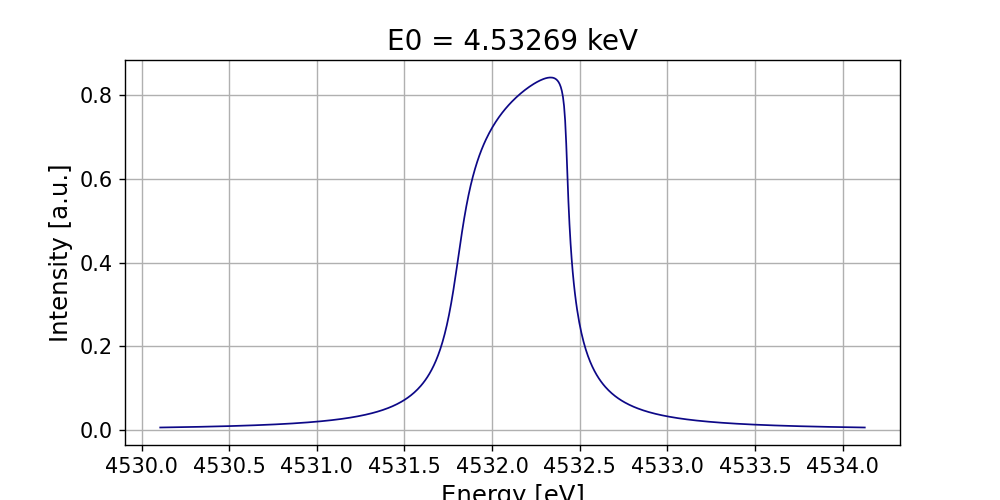

In [59]:
pat = re.compile(r"ш_Дарв_*(\d+[\.,]?\d*)\s*кэВ\.txt")

files = [] # [(энергия, путь)]

for path in glob.glob("Филипп/ш_Дарв_* кэВ.txt"):
    m = pat.search(path)
    if not m:
        continue
    try:
        E = float(m.group(1).replace(",", "."))
        files.append((E, path))
    except ValueError:
        pass

# сортировка по энергии
files.sort(key=lambda x: x[0])

D_Widths = {}

for E, path in files:
    try:
        d = np.loadtxt(path, skiprows=19)

        dtheta = d[:, 0]
        dE = d[:, 1] + 1000 * E
        zeta = d[:, 2]
        I = d[:, 3]
        rc = d[:, 4]

        idx = np.argsort(dE)

        D_Widths[E] = {
            "dtheta": dtheta[idx],
            "denergy": dE[idx],
            "zeta": zeta[idx],
            "intensity": I[idx],
            "rocking_curve": rc[idx],
        }

    except Exception as e:
        print(f"[!] Ошибка при обработке файла {path}: {e}")
        
# проверка на адекваность загрузки данных

for E, block in D_Widths.items():
    print(f"\nЭнергия {E} кэВ:")
    print("dtheta:", block["dtheta"][:5])
    print("denergy:", block["denergy"][:5])
    print("intensity:", block["intensity"][:5])
    print(len(block["intensity"]))

E = 4.53269                         
entry = D_Widths[E]                   

denergy = entry["denergy"]
intensity = entry["intensity"]
plt.figure(figsize=(8,4))
plt.plot(denergy, intensity, linewidth=1)
plt.xlabel("Energy [eV]")
plt.ylabel("Intensity [a.u.]")
plt.title(f"E0 = {E} keV")
plt.grid(True)
plt.show()

## 4. Поток фотонов, поглощенный фотодиодом $ F(E,I)_{Be} - F(E,I)_{Be+Si} $
### Расчет на ток накопителя 1 мА

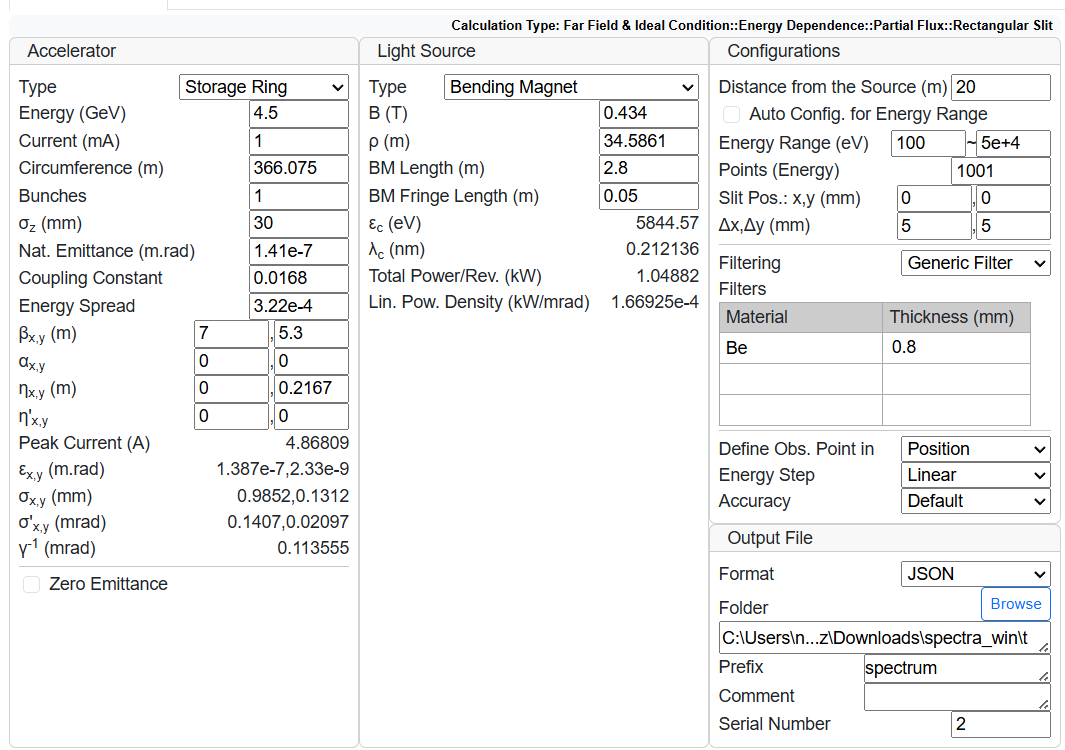

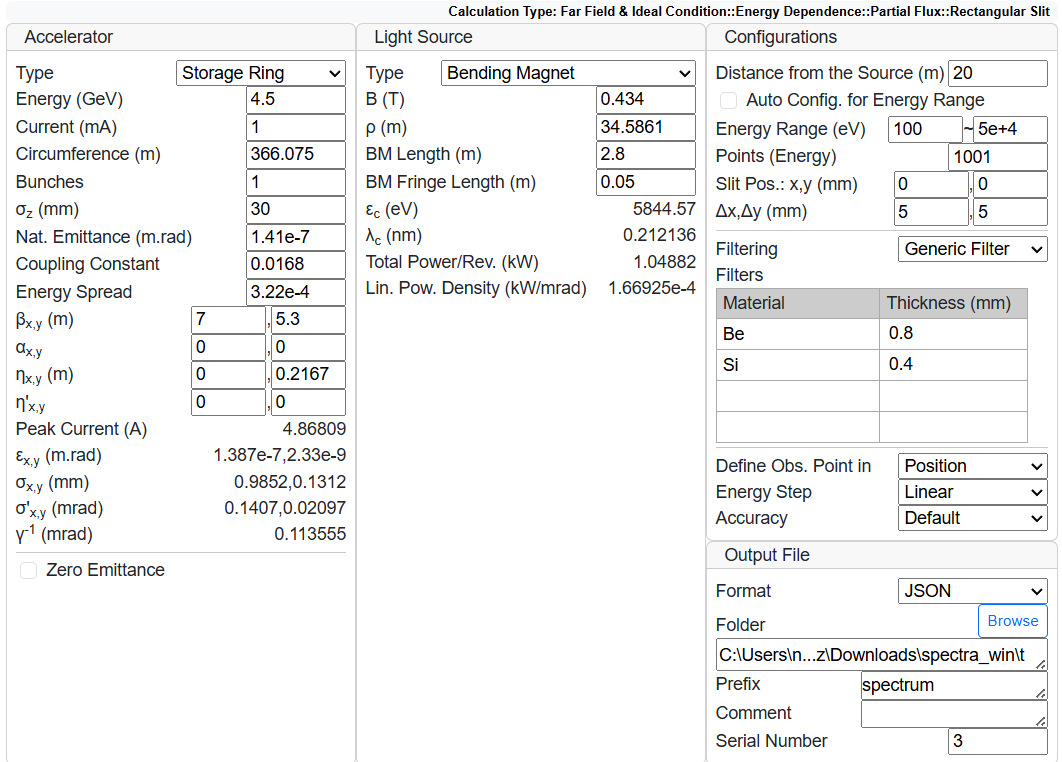

<IPython.core.display.Javascript object>


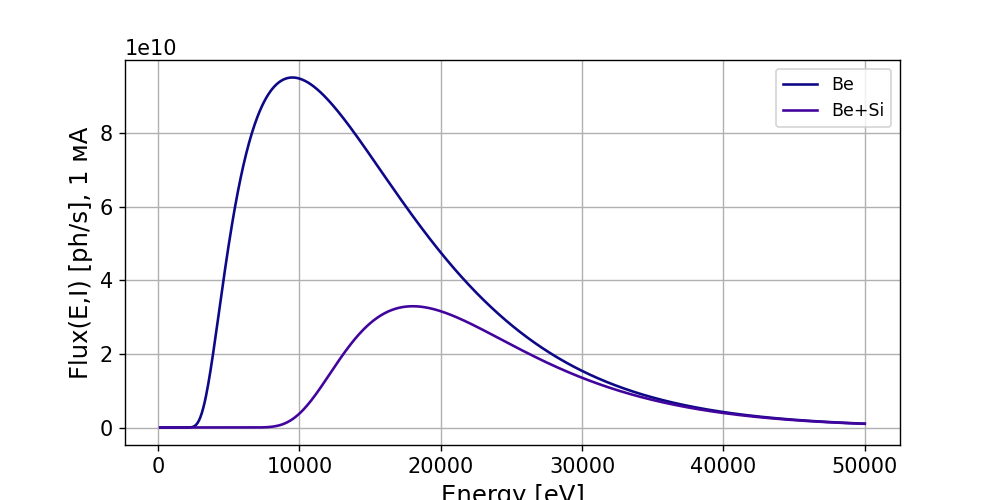

C:\Users\nmurz\AppData\Local\Temp\ipykernel_20908\2847697411.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,4))


<IPython.core.display.Javascript object>


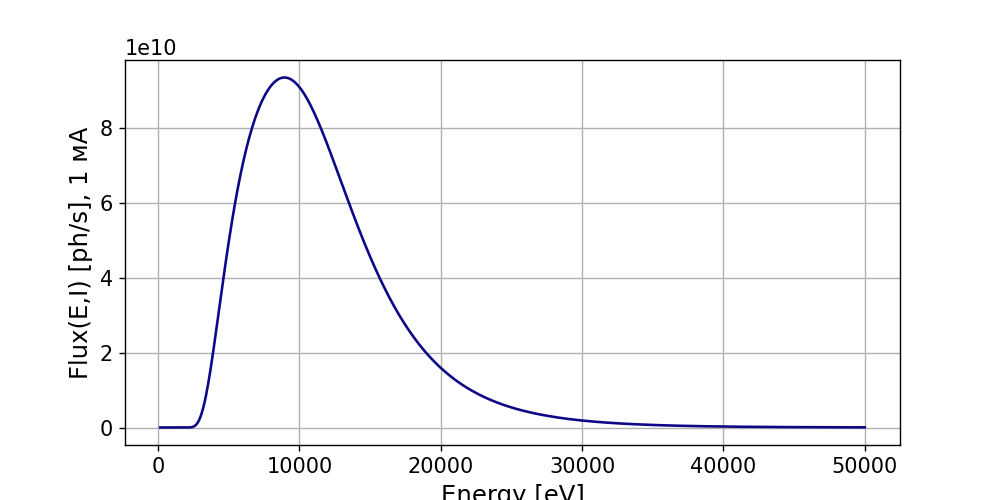

In [60]:
SPEC1 = np.loadtxt("spectrum-2.txt", skiprows=2)
SPEC2 = np.loadtxt("spectrum-3.txt", skiprows=2)
flux_Be = SPEC1[:, 1] # ph/s/mr^2/0.1% BW
flux_Be_Si = SPEC2[:, 1]
flux_spec = flux_Be-flux_Be_Si
energy_spec = SPEC1[:, 0]

plt.figure(figsize=(8,4))
plt.plot(energy_spec,flux_Be*0.001*energy_spec,label='Be')
plt.plot(energy_spec,flux_Be_Si*0.001*energy_spec,label='Be+Si')
plt.xlabel("Energy [eV]")
plt.ylabel("Flux(E,I) [ph/s], 1 мА")
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(8,4))
plt.plot(energy_spec,flux_spec*0.001*energy_spec)
plt.xlabel("Energy [eV]")
plt.ylabel("Flux(E,I) [ph/s], 1 мА")
plt.grid()
plt.show()

## 4.2. Учет тока накопителя

<IPython.core.display.Javascript object>


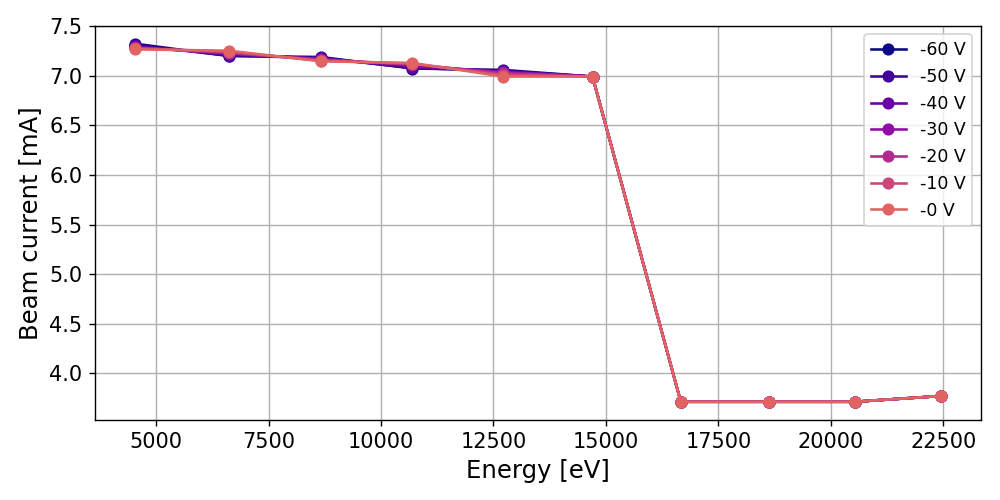

C:\Users\nmurz\AppData\Local\Temp\ipykernel_20908\936988477.py:38: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 4))


<IPython.core.display.Javascript object>


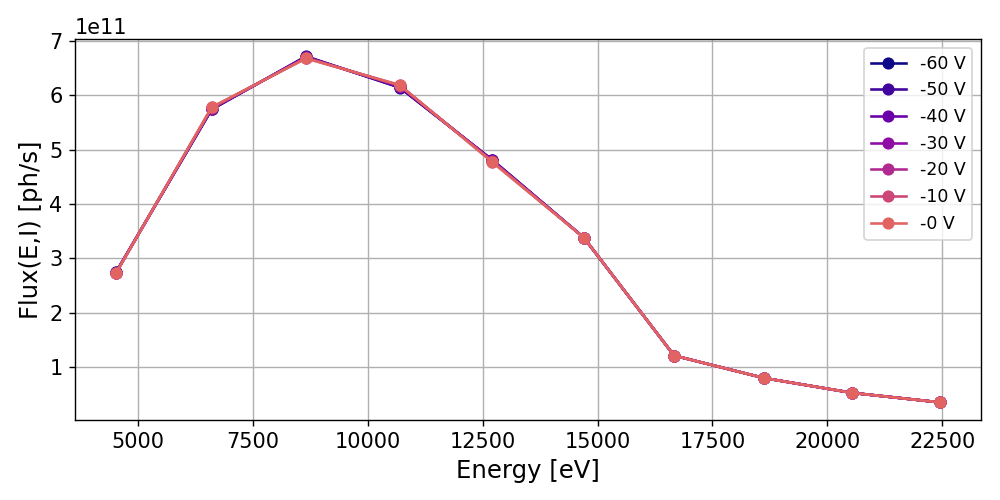

In [61]:
flux_spline = UnivariateSpline(energy_spec, flux_spec, s=0)

plot_data = {}

for V, rows in grouped_by_voltage.items():
    rows = np.asarray(rows)

    E = rows[:, 0] * 1000.0          # eV
    beam = rows[:, 3]
    flux = flux_spline(E)
    signal = flux * beam

    idx = np.argsort(E)

    plot_data[V] = {
        "E": E[idx],
        "beam": beam[idx],
        "signal": signal[idx],
    }

plt.figure(figsize=(8, 4))

for V in sorted(plot_data):
    plt.plot(
        plot_data[V]["E"],
        plot_data[V]["beam"],
        marker="o",
        label=f"{V:.0f} V"
    )

plt.xlabel("Energy [eV]")
plt.ylabel("Beam current [mA]")
plt.grid(True)
plt.legend()
plt.tight_layout()


plt.figure(figsize=(8, 4))

for V in sorted(plot_data):
    E = plot_data[V]["E"]
    S = plot_data[V]["signal"]

    plt.plot(
        E,
        S * E * 1e-3,
        marker="o",
        label=f"{V:.0f} V"
    )

plt.xlabel("Energy [eV]")
plt.ylabel("Flux(E,I) [ph/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


## 5. Интегрирование

<IPython.core.display.Javascript object>


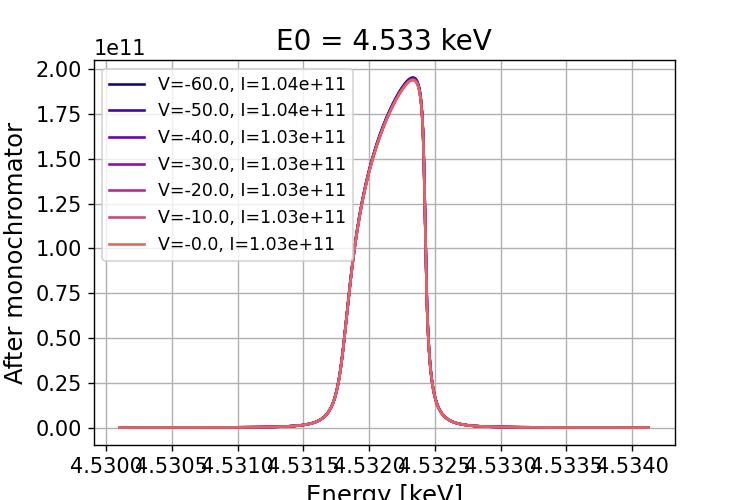

<IPython.core.display.Javascript object>


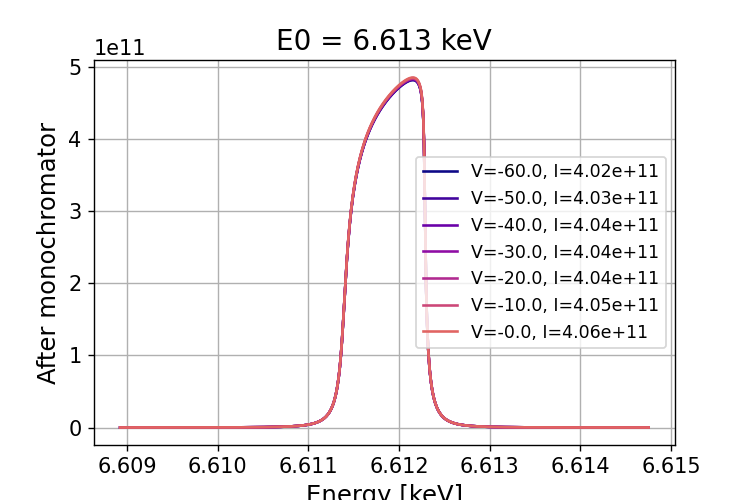

<IPython.core.display.Javascript object>


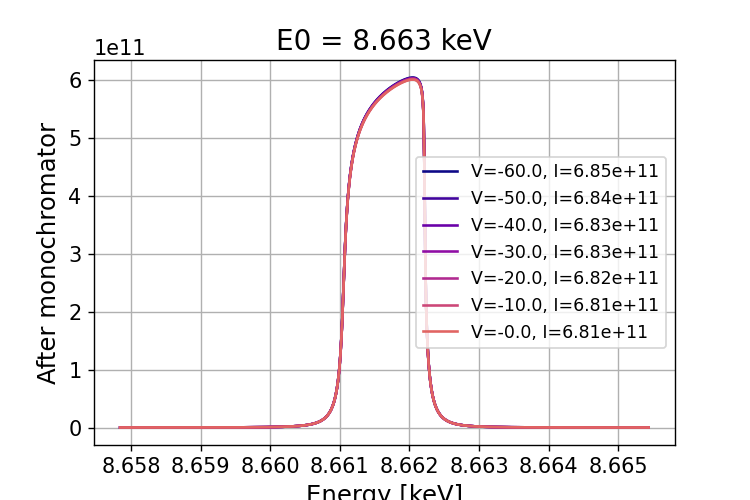

<IPython.core.display.Javascript object>


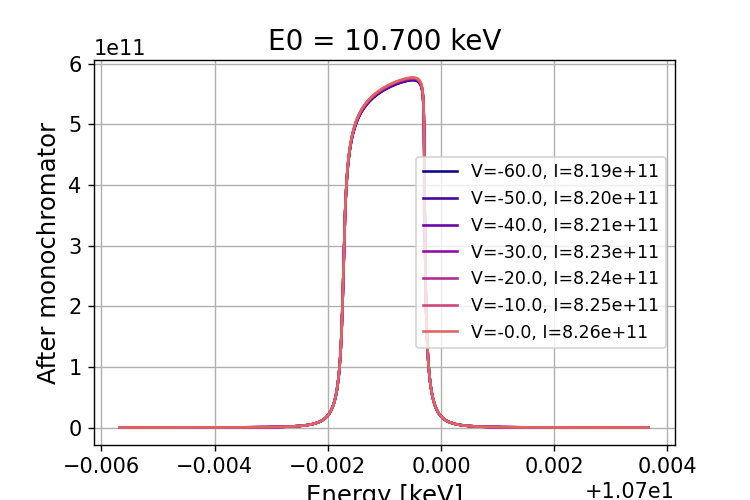

<IPython.core.display.Javascript object>


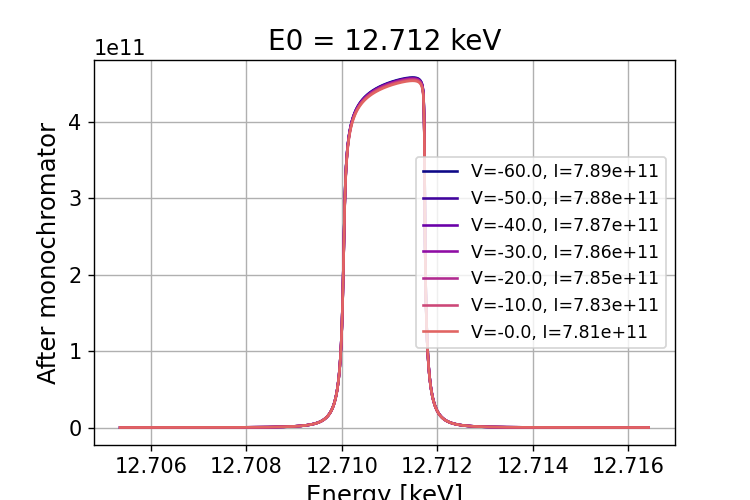

<IPython.core.display.Javascript object>


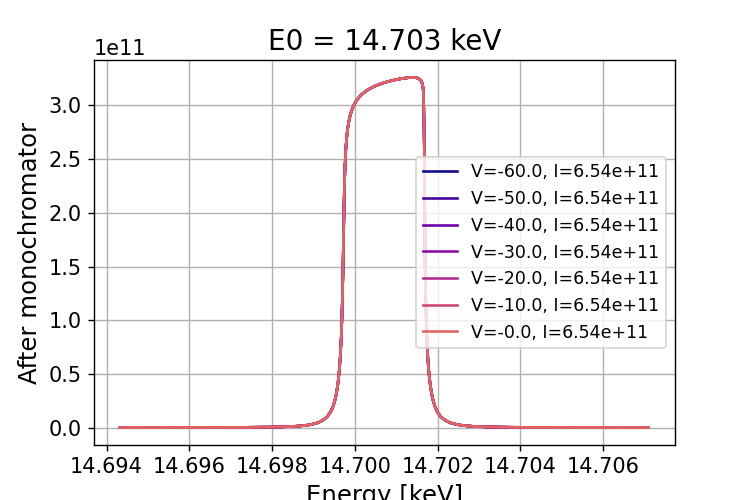

<IPython.core.display.Javascript object>


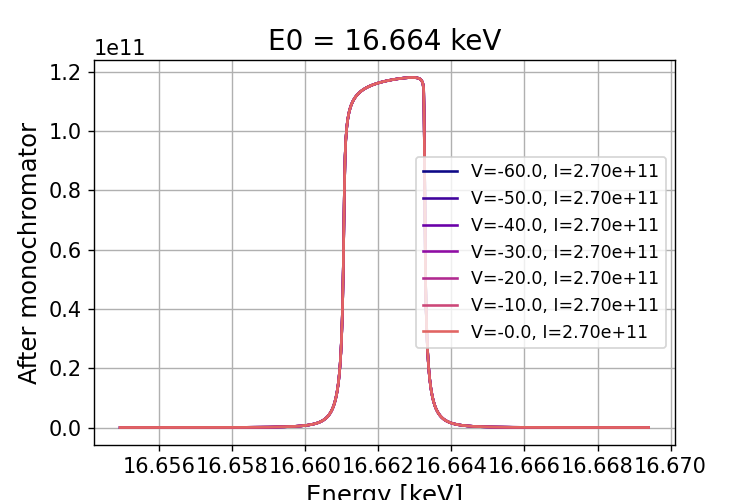

<IPython.core.display.Javascript object>


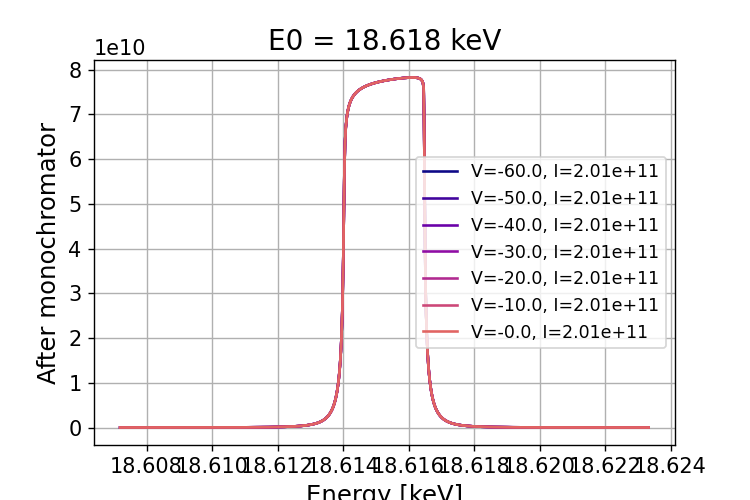

<IPython.core.display.Javascript object>


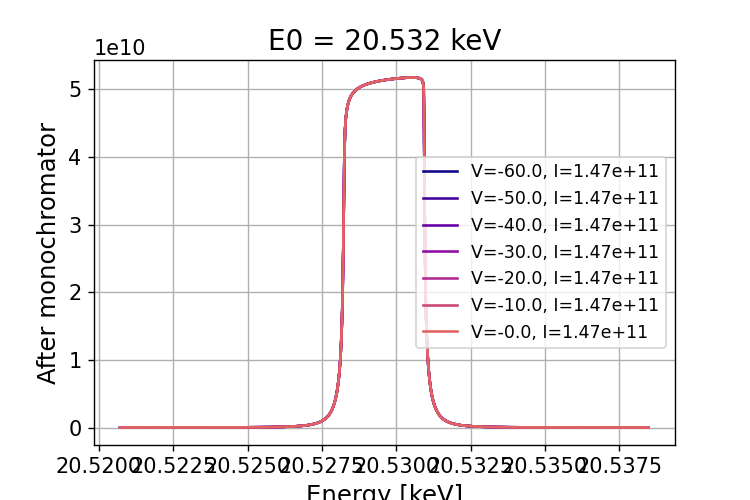

<IPython.core.display.Javascript object>


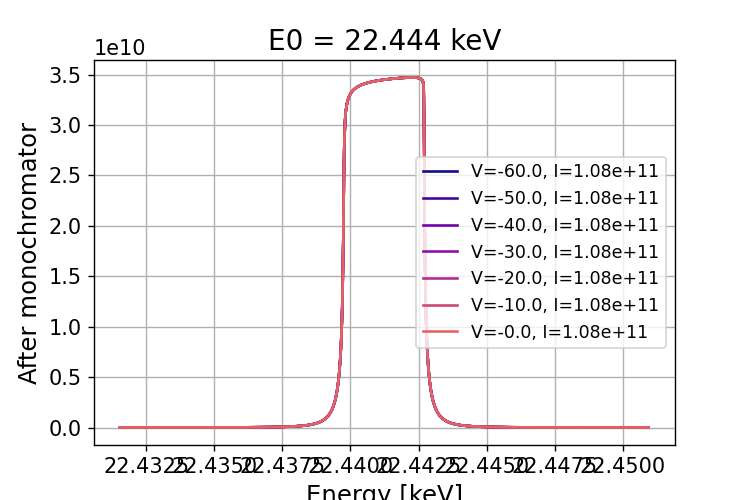

<IPython.core.display.Javascript object>


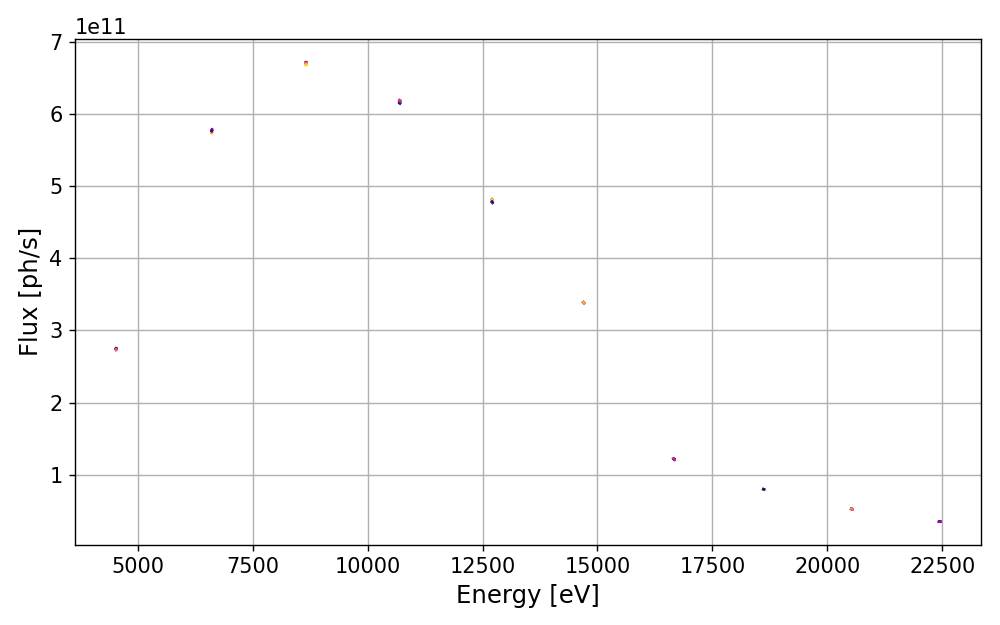

C:\Users\nmurz\AppData\Local\Temp\ipykernel_20908\3600898148.py:79: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 5))


<IPython.core.display.Javascript object>


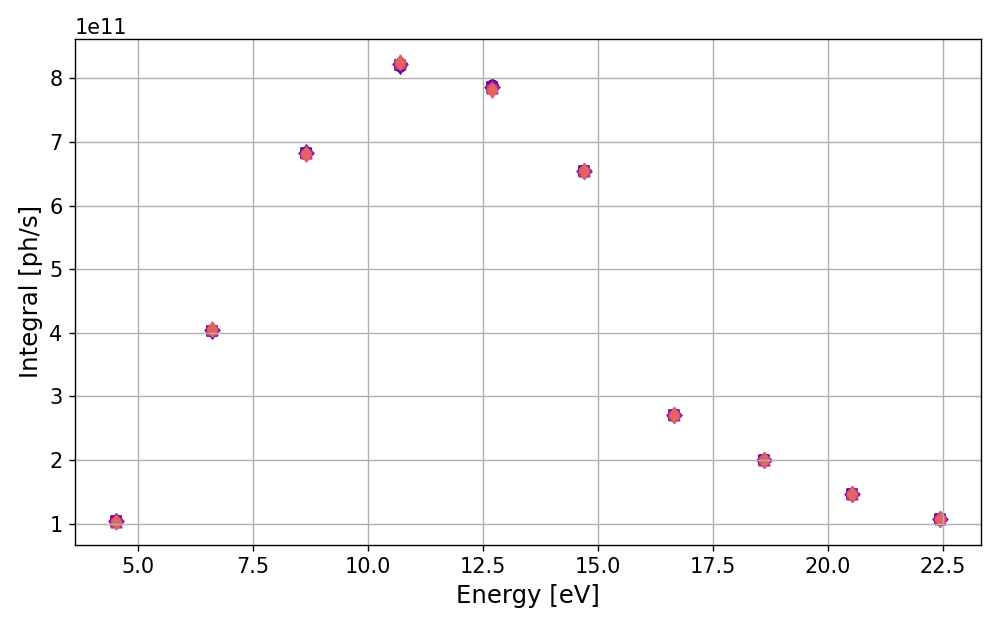


ИТОГ
E=4.533 keV,  V=-60.0,  Integral=1.038e+11
E=4.533 keV,  V=-50.0,  Integral=1.035e+11
E=4.533 keV,  V=-40.0,  Integral=1.034e+11
E=4.533 keV,  V=-30.0,  Integral=1.033e+11
E=4.533 keV,  V=-20.0,  Integral=1.032e+11
E=4.533 keV,  V=-10.0,  Integral=1.031e+11
E=4.533 keV,  V=-0.0,  Integral=1.030e+11
E=6.613 keV,  V=-60.0,  Integral=4.025e+11
E=6.613 keV,  V=-50.0,  Integral=4.027e+11
E=6.613 keV,  V=-40.0,  Integral=4.035e+11
E=6.613 keV,  V=-30.0,  Integral=4.039e+11
E=6.613 keV,  V=-20.0,  Integral=4.042e+11
E=6.613 keV,  V=-10.0,  Integral=4.049e+11
E=6.613 keV,  V=-0.0,  Integral=4.055e+11
E=8.663 keV,  V=-60.0,  Integral=6.846e+11
E=8.663 keV,  V=-50.0,  Integral=6.837e+11
E=8.663 keV,  V=-40.0,  Integral=6.832e+11
E=8.663 keV,  V=-30.0,  Integral=6.827e+11
E=8.663 keV,  V=-20.0,  Integral=6.821e+11
E=8.663 keV,  V=-10.0,  Integral=6.810e+11
E=8.663 keV,  V=-0.0,  Integral=6.805e+11
E=10.700 keV,  V=-60.0,  Integral=8.194e+11
E=10.700 keV,  V=-50.0,  Integral=8.200e+11
E=10.7

In [62]:
results = []
all_S_curves = []

for E_point, data in D_Widths.items():

    E_darwin = np.array(data["denergy"], float)  # eV
    curve = np.array(data["intensity"], float)

    # Интерполяция кривой Darwin
    darwin_interp = interp1d(E_darwin, curve, bounds_error=False, fill_value=0)

    # равномерная сетка для каждой кривой
    N = 1500
    E_min, E_max = E_darwin.min(), E_darwin.max()
    E_uniform = np.linspace(E_min, E_max, N)
    curve_uniform = darwin_interp(E_uniform)

    plt.figure(figsize=(6, 4))

    for V in plot_data:

        E_sig = np.array(plot_data[V]["E"], float)
        S_sig = np.array(plot_data[V]["signal"], float)

        # ph/s/0.1%bw → ph/s
        Y = S_sig * E_sig * 1e-3

        idx = np.argsort(E_sig)
        E_sorted = E_sig[idx]
        Y_sorted = Y[idx]
        
        # интерполяция потока на равномерную сетку        
        signal_interp = interp1d(
            E_sorted, Y_sorted,
            bounds_error=False,
            fill_value=(Y_sorted[0], Y_sorted[-1]))
        
        S_uniform = signal_interp(E_uniform)

        all_S_curves.append(
            (E_uniform.copy(), S_uniform.copy(), E_point, V)
        )

        product = (curve_uniform**2) * S_uniform
        integral = trapezoid(product, x=E_uniform)

        results.append({
            "E_point": E_point,
            "V": V,
            "integral": integral
        })

        plt.plot(E_uniform * 1e-3, product,
                 label=f"V={V}, I={integral:.2e}")

    plt.xlabel("Energy [keV]")
    plt.ylabel("After monochromator")
    plt.title(f"E0 = {E_point:.3f} keV")
    plt.grid(True)
    plt.legend()
    plt.show()


plt.figure(figsize=(8, 5))

for E_uniform, S_uniform, E_point, V in all_S_curves:
    plt.plot(
        E_uniform, S_uniform,
        label=f"E_point={E_point:.2f} keV, V={V}"
    )

plt.xlabel("Energy [eV]")
plt.ylabel("Flux [ph/s]")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

for i, V in enumerate(plot_data):
    data_V = [r for r in results if r['V'] == V]

    energies = [r['E_point'] for r in data_V]
    integral = [r['integral'] for r in data_V]

    plt.scatter(energies, integral,
             marker=markers[i % len(markers)],
             linestyle='-',
             label=f"V={V} В")

plt.xlabel("Energy [eV]")
plt.ylabel("Integral [ph/s]")
plt.grid(True)
plt.tight_layout()
plt.show()
    
print("\nИТОГ")
for r in results:
    print(f"E={r['E_point']:.3f} keV,  V={r['V']},  Integral={r['integral']:.3e}")



РЕЗУЛЬТАТЫ
E=4.53269 keV, V=-60.0, Integral=1.038e+11 ph/s, Current=1.228e-05 mA, QE=7.393e+01 ± 2.263e-01
E=4.53269 keV, V=-50.0, Integral=1.035e+11 ph/s, Current=1.143e-05 mA, QE=6.901e+01 ± 1.818e-01
E=4.53269 keV, V=-40.0, Integral=1.034e+11 ph/s, Current=1.053e-05 mA, QE=6.366e+01 ± 5.561e-01
E=4.53269 keV, V=-30.0, Integral=1.033e+11 ph/s, Current=9.116e-06 mA, QE=5.517e+01 ± 3.076e-01
E=4.53269 keV, V=-20.0, Integral=1.032e+11 ph/s, Current=7.917e-06 mA, QE=4.795e+01 ± 5.750e-01
E=4.53269 keV, V=-10.0, Integral=1.031e+11 ph/s, Current=6.155e-06 mA, QE=3.731e+01 ± 3.108e-01
E=4.53269 keV, V= -0.0, Integral=1.030e+11 ph/s, Current=3.909e-06 mA, QE=2.373e+01 ± 5.672e-01
E=6.61267 keV, V=-60.0, Integral=4.025e+11 ph/s, Current=1.230e-05 mA, QE=1.910e+01 ± 1.455e-02
E=6.61267 keV, V=-50.0, Integral=4.027e+11 ph/s, Current=1.157e-05 mA, QE=1.795e+01 ± 1.494e-01
E=6.61267 keV, V=-40.0, Integral=4.035e+11 ph/s, Current=1.065e-05 mA, QE=1.650e+01 ± 2.230e-02
E=6.61267 keV, V=-30.0, Inte

<IPython.core.display.Javascript object>


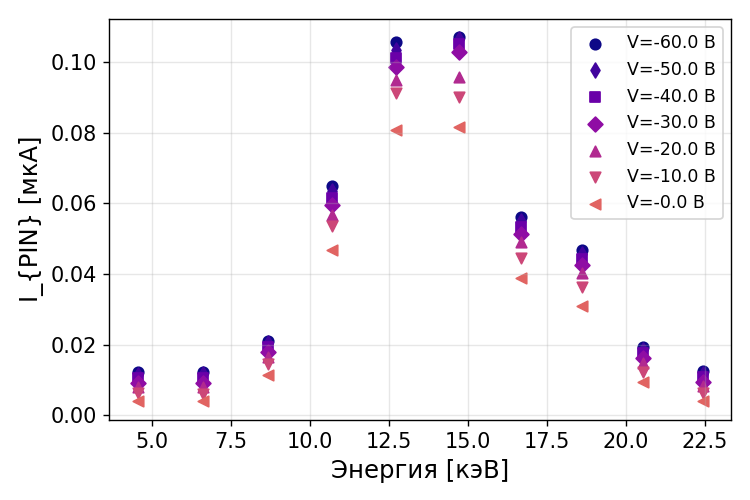

C:\Users\nmurz\AppData\Local\Temp\ipykernel_20908\1649142129.py:73: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 6))


<IPython.core.display.Javascript object>


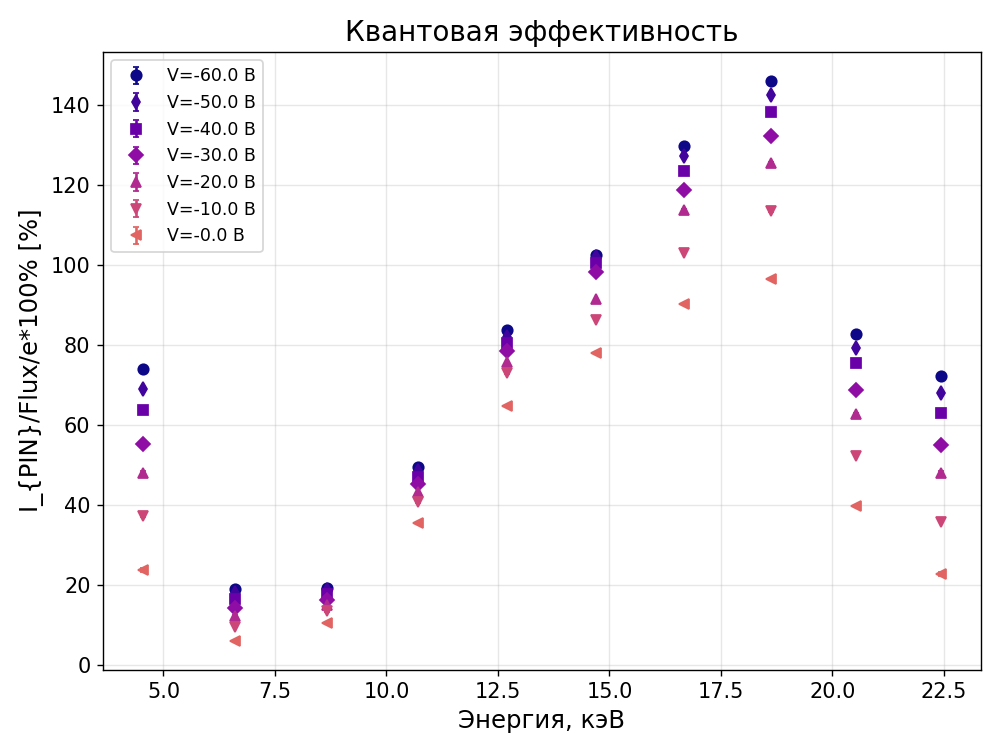

In [63]:
interpolations_dI = {}

for V, arr in grouped_by_voltage.items():
    arr = np.array(arr)
    energies = arr[:, 0]   # кэВ
    dI = arr[:, 2]         # ошибка фототока, мА

    interpolations_dI[V] = UnivariateSpline(
        energies, dI,
        k=1, s=0
    )

adjusted_results = []

for r in results:
    E_point = r['E_point']
    V = r['V']
    integral = r['integral']

    I_photo = -interpolations_V[V](E_point)      # mA
    dI_photo = interpolations_dI[V](E_point)     # mA

    I_A = I_photo * 1e-3 # A
    dI_A = dI_photo * 1e-3 # A

    value = I_A / (integral * 1.6e-19) * 100
    error = dI_A / (integral * 1.6e-19) * 100
    
    adjusted_results.append({
        "E_point": E_point,
        "V": V,
        "integral": integral,
        "current": I_photo,                  # mA
        "current_per_integral": value,        # %
        "error": error
    })


print("\nРЕЗУЛЬТАТЫ")
for r in adjusted_results:
    print(
    f"E={r['E_point']:.5f} keV, "
    f"V={r['V']:>5}, "
    f"Integral={r['integral']:.3e} ph/s, "
    f"Current={r['current']:.3e} mA, "
    f"QE={r['current_per_integral']:.3e} ± {r['error']:.3e}")
    
voltages_to_plot = sorted({r['V'] for r in adjusted_results})
markers = ["o", "d", "s", "D", "^", "v", "<", ">", "p", "*"]


plt.figure(figsize=(6, 4))

for i, V in enumerate(voltages_to_plot):
    data_V = [r for r in adjusted_results if r['V'] == V]

    energies = [r['E_point'] for r in data_V]
    current = [r['current']*1e3 for r in data_V] #uA

    plt.scatter(energies, current,
             marker=markers[i % len(markers)],
             linestyle='-',
             label=f"V={V} В")
    
plt.xlabel("Энергия [кэВ]")
plt.ylabel("I_{PIN} [мкА]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))

for i, V in enumerate(voltages_to_plot):
    data_V = [r for r in adjusted_results if r['V'] == V]

    energies = [r['E_point'] for r in data_V]
    current_per_integral = [r['current_per_integral'] for r in data_V]
    error = [r['error'] for r in data_V]

    plt.errorbar(energies, current_per_integral,
                 yerr = error,linestyle='none',
                 marker=markers[i % len(markers)],
                 label=f"V={V} В")    

plt.xlabel("Энергия, кэВ")
plt.ylabel("I_{PIN}/Flux/e*100% [%]")
plt.grid(alpha=0.3)
plt.title("Квантовая эффективность")
plt.legend()
plt.tight_layout()
plt.show()


#### Физически оправдана только квантовая эффективность при нулевом напряжении смещения. При других напряжениях надо учитывать темновой ток (?)

C:\Users\nmurz\AppData\Local\Temp\ipykernel_20908\3621772074.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


<IPython.core.display.Javascript object>


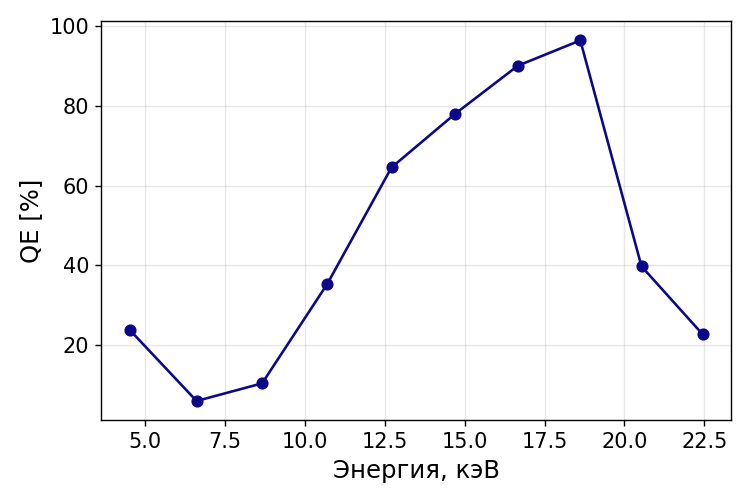

In [64]:
V = 0  # нулевое напряжение
data_V = [r for r in adjusted_results if r['V'] == V]

energies = [r['E_point'] for r in data_V]
current_per_integral = [r['current_per_integral'] for r in data_V]
error = [r['error'] for r in data_V]

plt.figure(figsize=(6, 4))
plt.errorbar(
    energies,
    current_per_integral,
    yerr=error,
    linestyle='-',#'none',
    marker='o',  
    label=f"V={V} В"
)

plt.xlabel("Энергия, кэВ")
plt.ylabel("QE [%]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
